# Phân tích tương quan giữa các biến trong dữ liệu bê tông
**Học phần:** Phân tích và trực quan hóa dữ liệu  
**Phần việc:** Phân tích tương quan · Tiếp nối `01_eda.ipynb` của nhóm

Notebook trả lời ba câu hỏi: (1) biến nào liên hệ với cường độ chịu nén, (2) các biến đầu vào liên hệ với nhau như thế nào, (3) kết luận thay đổi ra sao khi xét tuổi mẫu, biến dẫn xuất và ngoại lai?

**Cách dùng:** Đặt file trong thư mục `notebooks/` của repo và chọn **Run All** trong Jupyter/VS Code, hoặc tải trực tiếp lên Google Colab. Notebook đã chứa kết quả chạy và bản dữ liệu dự phòng nên không cần tải thêm CSV. Môi trường cần Python 3, `numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `IPython`. Nếu thiếu, chạy `%pip install numpy pandas scipy matplotlib seaborn ipython` ở một ô mới.

**Phạm vi:** Phân tích mô tả và thăm dò, không xây dựng mô hình dự đoán, không suy luận nhân quả. Dấu “.” trong bảng và biểu đồ là dấu thập phân.

## 1. Nguồn dữ liệu và lựa chọn biến
- Repo nhóm: https://github.com/vkyphong/concrete-compressive-strength-analysis
- Phiên bản được kiểm tra: `cd7509dc0d1734cf8c9382b5127c4bfbcd769e44`.
- Dữ liệu: `data/processed/cleaned.csv`; quy trình làm sạch: `notebooks/01_eda.ipynb` và `data/processed/README.md`.
- Theo quy trình của nhóm: 1.030 dòng gốc, loại 25 dòng trùng hoàn toàn, còn **1.005 dòng**; giữ số 0 hợp lệ và giữ ngoại lai.
- SHA-256 của CSV dùng trong bản báo cáo: `220dde6aff061a71630280993add035370fd20f2f201a0ad25557a2a44d59cd9`.

| Cột | Ý nghĩa | Đơn vị |
|---|---|---|
| cement | Xi măng | kg/m³ |
| slag | Xỉ lò cao nghiền mịn | kg/m³ |
| fly_ash | Tro bay | kg/m³ |
| water | Nước trộn | kg/m³ |
| superplasticizer | Phụ gia siêu dẻo | kg/m³ |
| coarse_agg | Cốt liệu thô | kg/m³ |
| fine_agg | Cốt liệu mịn | kg/m³ |
| age | Tuổi mẫu khi thử nén | ngày |
| strength | Cường độ chịu nén, biến mục tiêu | MPa |

Ma trận chính chỉ dùng **9 biến gốc**. `log_age`, `w_c` được xét riêng để tránh trộn quan hệ toán học với quan hệ giữa các đại lượng gốc. Không mã hóa tùy tiện `age_group`, `scm_type`, `strength_level` thành số; đặc biệt `strength_level` được tạo từ mục tiêu nên không dùng làm biến giải thích. Các cờ ngoại lai chỉ dùng để kiểm tra độ nhạy.

In [1]:
from pathlib import Path
import io, base64, zlib, hashlib, warnings, sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 140)
SEED = 2026
EXPORT = False  # Đổi thành True nếu muốn lưu thêm hình PNG và bảng CSV.
OUT = Path.cwd() / "correlation_outputs"
if EXPORT:
    OUT.mkdir(parents=True, exist_ok=True)

def show_fig(fig, name):
    if EXPORT:
        fig.savefig(OUT / f"{name}.png", bbox_inches="tight")
    plt.show()

def show_table(table, name):
    display(table.round(4))
    if EXPORT:
        table.to_csv(OUT / f"{name}.csv", encoding="utf-8-sig")

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__}")

Python 3.12.14 | pandas 2.2.3 | numpy 2.3.5 | scipy 1.17.0


In [2]:
# Bản CSV dự phòng được nén nguyên byte từ đúng commit nêu trên.
EMBEDDED_CSV = "..."
EXPECTED_SHA256 = "220dde6aff061a71630280993add035370fd20f2f201a0ad25557a2a44d59cd9"
candidates = [Path.cwd() / "data/processed/cleaned.csv",
              Path.cwd().parent / "data/processed/cleaned.csv",
              Path.cwd() / "cleaned.csv"]
local_file = next((p for p in candidates if p.is_file()), None)
if local_file is not None:
    csv_bytes = local_file.read_bytes()
    source = str(local_file)
else:
    csv_bytes = zlib.decompress(base64.b64decode(EMBEDDED_CSV))
    source = "Bản dữ liệu dự phòng trong notebook, từ commit đã ghi"
actual_sha = hashlib.sha256(csv_bytes).hexdigest()
if actual_sha != EXPECTED_SHA256:
    raise ValueError("CSV cục bộ khác phiên bản báo cáo. Đổi tên/di chuyển CSV đó để dùng bản dự phòng; hoặc cập nhật phân tích và nhận xét cho dữ liệu mới.")
df = pd.read_csv(io.BytesIO(csv_bytes))
features = ["cement", "slag", "fly_ash", "water", "superplasticizer", "coarse_agg", "fine_agg", "age"]
original = features + ["strength"]
labels = {"cement": "Xi măng", "slag": "Xỉ lò cao", "fly_ash": "Tro bay", "water": "Nước",
          "superplasticizer": "Phụ gia siêu dẻo", "coarse_agg": "Cốt liệu thô", "fine_agg": "Cốt liệu mịn",
          "age": "Tuổi mẫu", "strength": "Cường độ", "log_age": "log(1 + tuổi)", "w_c": "Nước/xi măng"}
assert df.shape == (1005, 17)
assert df[original].isna().sum().sum() == 0
assert np.isfinite(df[original].to_numpy()).all()
assert not df[original].duplicated().any()
assert df[original].nunique().gt(1).all()
assert np.allclose(df["log_age"], np.log1p(df["age"]))
assert np.allclose(df["w_c"], df["water"] / df["cement"])
print("Nguồn:", source)
print(f"Kiểm tra đạt: {len(df):,} dòng, 9 biến gốc, không thiếu, không trùng hoàn toàn.")
show_table(df[original].agg(["count", "min", "median", "max"]).T, "01_data_check")

,count,min,median,max
cement,1005.0,102.0000,265.0000,540.0000
slag,1005.0,0.0000,20.0000,359.4000
fly_ash,1005.0,0.0000,0.0000,200.1000
water,1005.0,121.7500,185.7000,247.0000
superplasticizer,1005.0,0.0000,6.1000,32.2000
coarse_agg,1005.0,801.0000,968.0000,1145.0000
fine_agg,1005.0,594.0000,780.0000,992.6000
age,1005.0,1.0000,28.0000,365.0000
strength,1005.0,2.3318,33.7981,82.5992


Nguồn: /workspace/scratch/d5682cd59ee6/repo/data/processed/cleaned.csv
Kiểm tra đạt: 1,005 dòng, 9 biến gốc, không thiếu, không trùng hoàn toàn.


## 2. Phương pháp và cách đọc kết quả
**Pearson** đo mức độ liên hệ tuyến tính trên giá trị gốc:
\[
r=\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_i(x_i-\bar{x})^2\sum_i(y_i-\bar{y})^2}}.
\]
**Spearman** là Pearson trên thứ hạng, với các giá trị bằng nhau nhận hạng trung bình. Phương pháp này đo quan hệ đơn điệu, giảm ảnh hưởng của độ lớn cực trị nhưng không miễn nhiễm với ngoại lai và không tự giải quyết vấn đề nhiều số 0.

Cả hai thuộc [−1, 1]: dấu cho biết chiều, trị tuyệt đối cho biết độ mạnh theo thước đo đang dùng. Hệ số gần 0 không loại trừ quan hệ phi tuyến hoặc tương tác. Không cần chuẩn hóa các biến trước khi tính hệ số.

Báo cáo đối chiếu hai phương pháp vì tuổi lệch phải, vật liệu tùy chọn có nhiều số 0 và quan hệ có thể phi tuyến. Không dùng ngưỡng “mạnh/yếu” như quy luật phổ quát.

**Kiểm định bổ sung:** kiểm định hai phía H₀: hệ số tương quan bằng 0, hiệu chỉnh Benjamini–Hochberg (BH) riêng cho 8 kiểm định Pearson và 8 kiểm định Spearman với mục tiêu. P-value Spearman là xấp xỉ; p-value chỉ mang tính tham khảo vì dữ liệu có thể có nhiều tuổi thử trên cùng cấp phối, không đảm bảo độc lập giữa các dòng. Ưu tiên độ lớn hệ số và biểu đồ, không chọn biến chỉ bằng p-value.

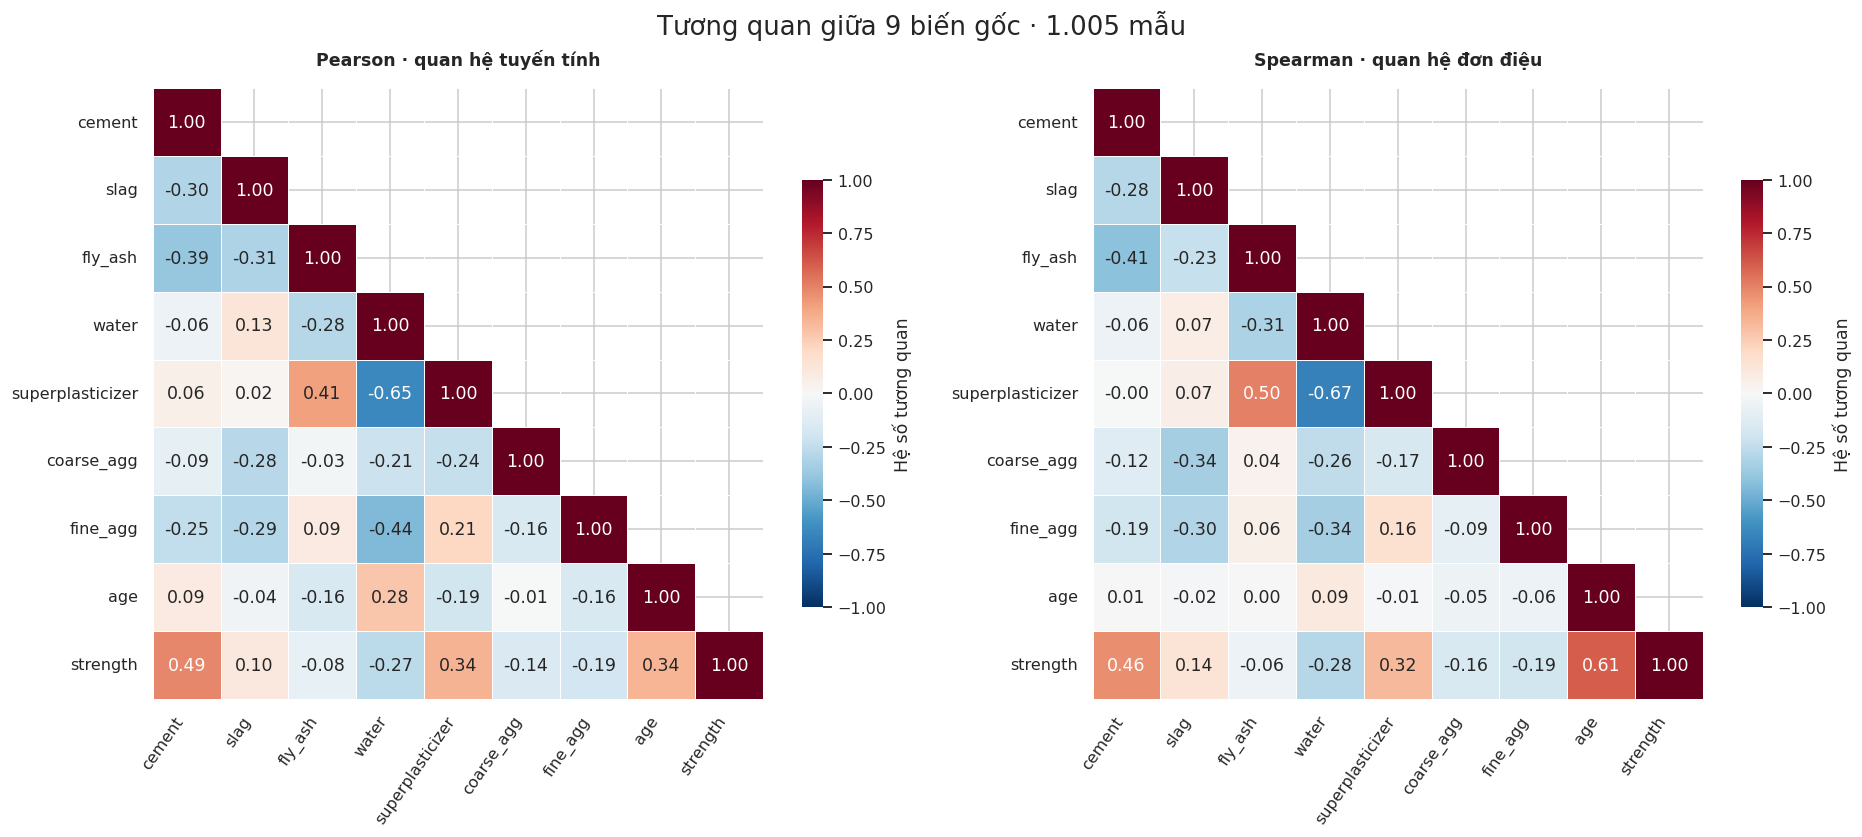

In [3]:
pearson = df[original].corr(method="pearson")
spearman = df[original].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), layout="constrained")
mask = np.triu(np.ones((len(original), len(original)), dtype=bool), k=1)
for ax, matrix, title in zip(axes, [pearson, spearman], ["Pearson · quan hệ tuyến tính", "Spearman · quan hệ đơn điệu"]):
    sns.heatmap(matrix, mask=mask, ax=ax, annot=True, fmt=".2f", vmin=-1, vmax=1,
                cmap="RdBu_r", center=0, square=True, linewidths=.5,
                cbar_kws={"shrink": .7, "label": "Hệ số tương quan"})
    ax.set_title(title, pad=15)
    ax.tick_params(axis="x", rotation=55)
    for t in ax.get_xticklabels(): t.set_ha("right")
fig.suptitle("Tương quan giữa 9 biến gốc · 1.005 mẫu", fontsize=17)
show_fig(fig, "02_heatmaps")

**Nhận xét:** `cement` và `age` cùng liên hệ dương với `strength`, còn `water` liên hệ âm. Hai ma trận không giống nhau, nổi bật ở `age`: tương quan trên thứ hạng lớn hơn trên giá trị gốc. Trong các đầu vào, nước và phụ gia siêu dẻo có quan hệ âm đáng chú ý. Các phần tiếp theo lượng hóa thay vì chỉ dựa vào màu heatmap.

## 3. Mức độ tương quan với cường độ chịu nén
Bảng được xếp giảm dần theo |Spearman|. BH điều chỉnh cho việc kiểm định đồng thời nhiều biến; `p_BH < 0.05` không đồng nghĩa với tác động lớn hoặc quan hệ nhân quả.

,n,Pearson_r,Spearman_rho,p_Pearson,p_Spearman,p_BH_Pearson,p_BH_Spearman
bien,,,,,,,
age,1005,0.337,0.605,3.57e-28,1.56e-101,9.51e-28,1.25e-100
cement,1005,0.488,0.461,2.46e-61,3.96e-54,1.97e-60,1.59e-53
superplasticizer,1005,0.344,0.322,2.47e-29,1.20e-25,9.87e-29,3.19e-25
water,1005,-0.270,-0.284,3.38e-18,3.96e-20,6.76e-18,7.93e-20
fine_agg,1005,-0.186,-0.193,2.59e-09,6.44e-10,4.14e-09,1.03e-09
coarse_agg,1005,-0.145,-0.163,4.10e-06,2.10e-07,5.47e-06,2.79e-07
slag,1005,0.103,0.139,1.03e-03,1.03e-05,1.18e-03,1.18e-05
fly_ash,1005,-0.081,-0.056,1.05e-02,7.36e-02,1.05e-02,7.36e-02


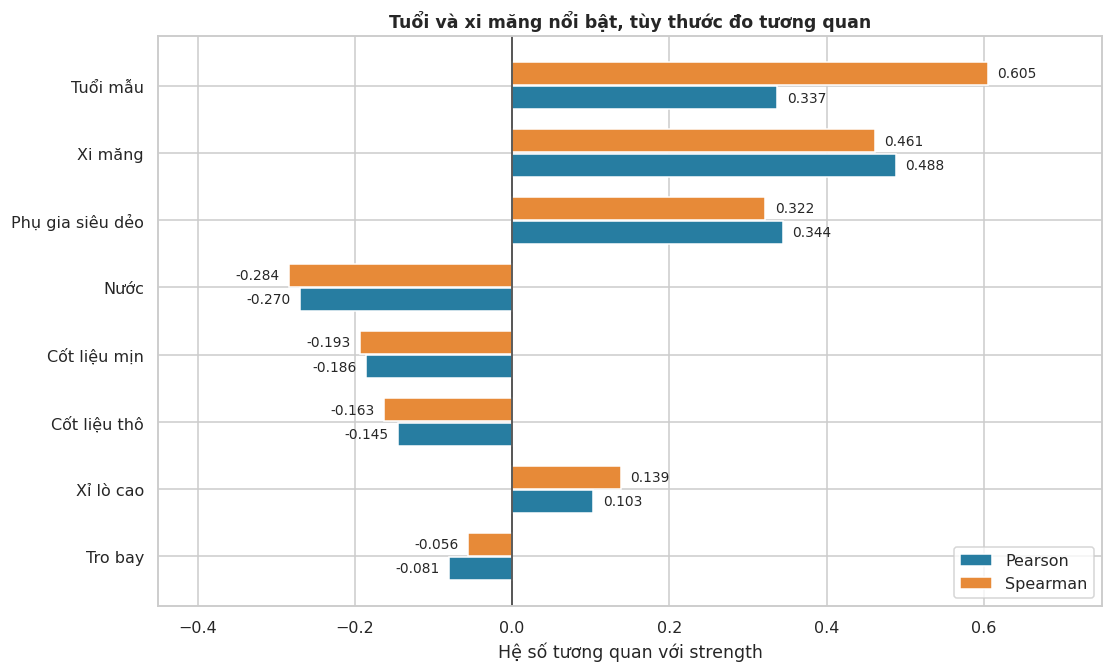

In [4]:
def bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted_sorted = np.minimum.accumulate((p[order] * len(p) / np.arange(1, len(p)+1))[::-1])[::-1]
    adjusted = np.empty_like(p)
    adjusted[order] = np.minimum(adjusted_sorted, 1)
    return adjusted

rows = []
for v in features:
    r, p = stats.pearsonr(df[v], df["strength"])
    rho, ps = stats.spearmanr(df[v], df["strength"])
    rows.append({"bien": v, "n": len(df), "Pearson_r": r, "Spearman_rho": rho,
                 "p_Pearson": p, "p_Spearman": ps})
target_table = pd.DataFrame(rows).set_index("bien")
target_table["p_BH_Pearson"] = bh_adjust(target_table["p_Pearson"])
target_table["p_BH_Spearman"] = bh_adjust(target_table["p_Spearman"])
target_table = target_table.loc[target_table["Spearman_rho"].abs().sort_values(ascending=False).index]
formatted = target_table.copy()
for col in formatted:
    if col.startswith("p_"): formatted[col] = formatted[col].map(lambda x: f"{x:.2e}")
    elif col != "n": formatted[col] = formatted[col].round(3)
display(formatted)
if EXPORT: target_table.to_csv(OUT / "03_target_correlations.csv", encoding="utf-8-sig")

plot_data = target_table.iloc[::-1]
y = np.arange(len(plot_data))
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.barh(y-.18, plot_data["Pearson_r"], height=.34, label="Pearson", color="#277DA1")
ax.barh(y+.18, plot_data["Spearman_rho"], height=.34, label="Spearman", color="#E78A38")
for offset, col in [(-.18, "Pearson_r"), (.18, "Spearman_rho")]:
    for i, val in enumerate(plot_data[col]):
        ax.text(val + (.012 if val >= 0 else -.012), i+offset, f"{val:.3f}",
                ha="left" if val >= 0 else "right", va="center", fontsize=9)
ax.set_yticks(y, [labels[v] for v in plot_data.index])
ax.axvline(0, color="#333333", lw=1)
ax.set(xlim=(-.45,.75), xlabel="Hệ số tương quan với strength", title="Tuổi và xi măng nổi bật, tùy thước đo tương quan")
ax.legend(loc="lower right")
show_fig(fig, "03_target_ranking")

**Diễn giải:**
- `age` đứng đầu về Spearman (≈ 0,605); `cement` đứng đầu về Pearson trong 8 biến gốc (≈ 0,488). Vì vậy, cần nêu rõ thước đo khi nói biến nào có tương quan lớn nhất.
- `superplasticizer` có tương quan dương, còn `water`, `coarse_agg`, `fine_agg` có tương quan âm với cường độ trên toàn mẫu. Đây là liên hệ biên, chưa giữ cố định các thành phần khác.
- `slag` và `fly_ash` có hệ số biên nhỏ. Không thể kết luận chúng “không ảnh hưởng”: hiệu quả có thể phụ thuộc tuổi và công thức cấp phối.
- Hệ số 0,605 không có nghĩa tuổi giải thích 60,5% cường độ. Bình phương Spearman cũng không phải R² của hồi quy tuyến tính trên các giá trị gốc.

## 4. Quan sát trực tiếp quan hệ của từng biến với strength
Mỗi điểm là một quan sát. Đường đỏ là hồi quy tuyến tính mô tả trên toàn mẫu, không phải mô hình nhân quả; không vẽ khoảng tin cậy để tránh ngầm coi các thí nghiệm là độc lập. Với tuổi, các dải điểm thẳng đứng phản ánh lịch thử rời rạc.

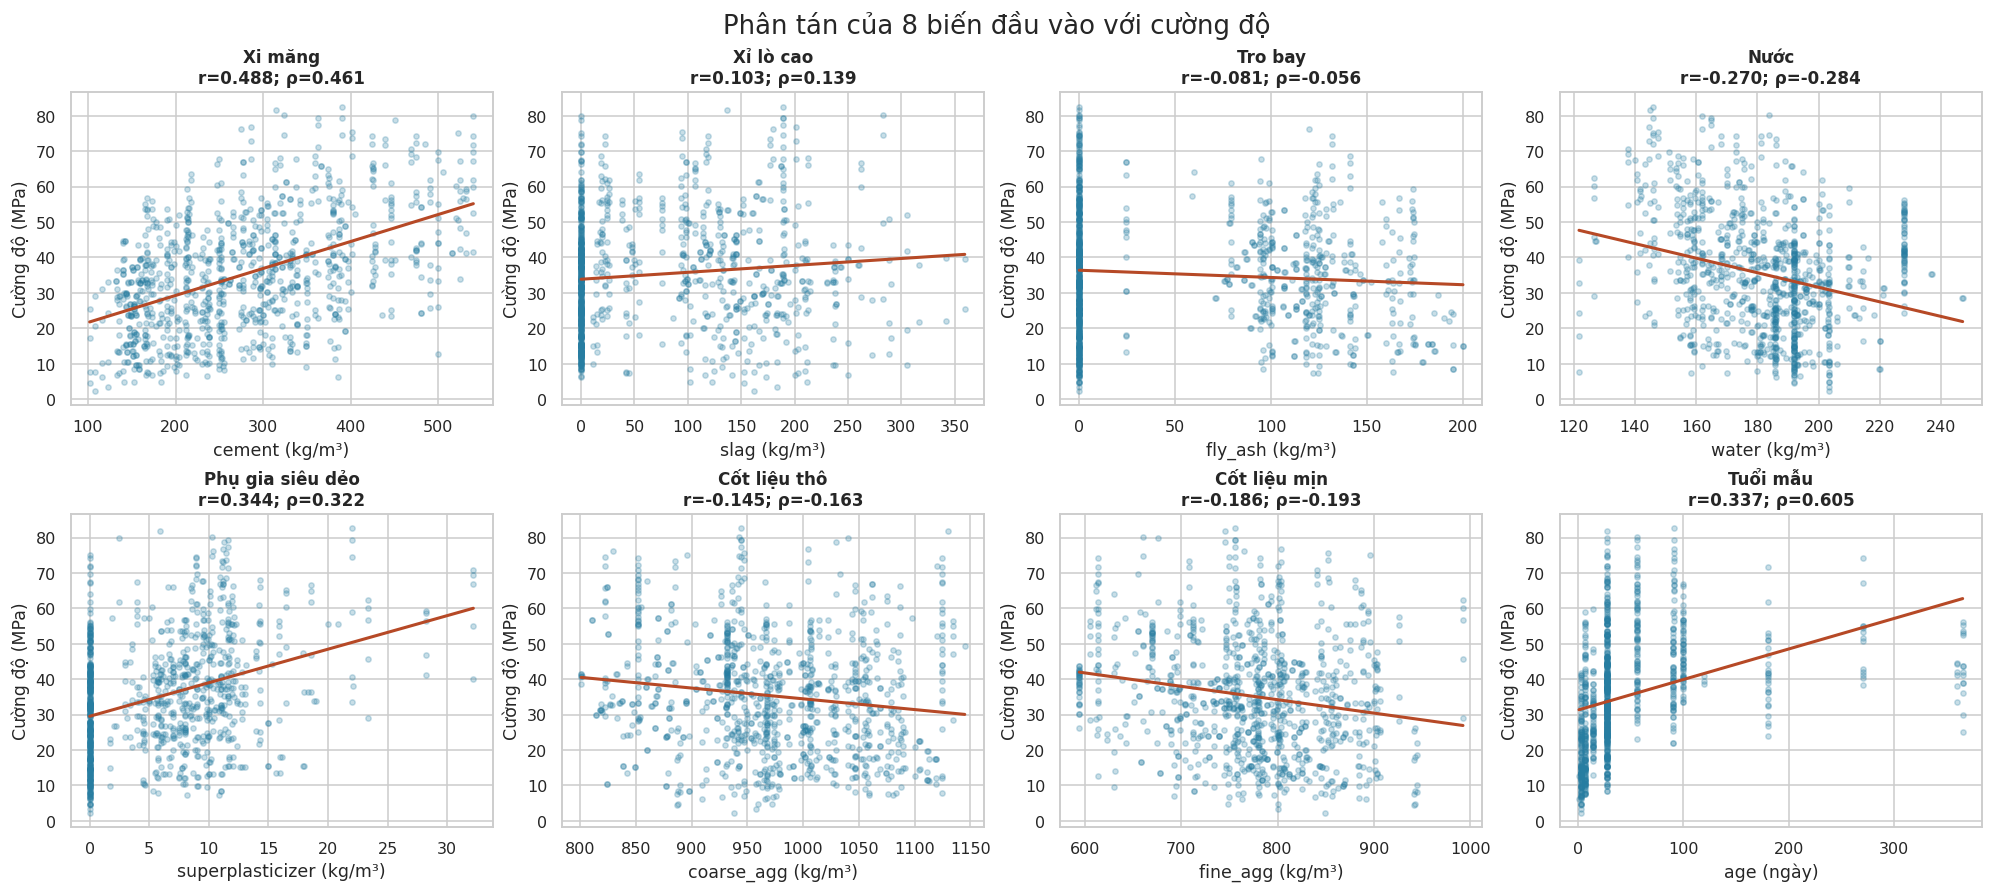

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), layout="constrained")
for ax, v in zip(axes.flat, features):
    sns.regplot(data=df, x=v, y="strength", ax=ax, ci=None,
                scatter_kws={"s":12, "alpha":.25, "color":"#277DA1"},
                line_kws={"color":"#B64926", "lw":2})
    ax.set_title(f"{labels[v]}\nr={pearson.loc[v,'strength']:.3f}; ρ={spearman.loc[v,'strength']:.3f}", fontsize=11)
    ax.set_xlabel(f"{v} ({'ngày' if v == 'age' else 'kg/m³'})")
    ax.set_ylabel("Cường độ (MPa)")
fig.suptitle("Phân tán của 8 biến đầu vào với cường độ", fontsize=17)
show_fig(fig, "04_scatter_all_inputs")

**Nhận xét:** Độ phân tán lớn ở cùng một lượng vật liệu cho thấy mỗi biến riêng lẻ không mô tả đầy đủ cường độ. Với tro bay, xỉ và phụ gia, cụm điểm tại 0 biểu thị không sử dụng vật liệu. Đường thẳng với tuổi không mô tả tốt toàn bộ hình dạng dữ liệu; cần xem thêm biến đổi log và phân tầng theo tuổi.

## 5. Biến dẫn xuất: log tuổi và tỷ lệ nước/xi măng
`log_age = log(1 + age)` và `w_c = water / cement` đã được nhóm tạo ở bước EDA. Đây là phân tích bổ sung, không thêm vào bảng xếp hạng 8 đầu vào gốc.

Phép log tăng nghiêm ngặt nên không đổi thứ hạng của tuổi: Spearman phải giữ nguyên. Tỷ lệ `w_c` có chung thành phần toán học với `water` và `cement`; tương quan mạnh giữa chúng không phải bằng chứng độc lập về cơ chế vật liệu.

,Pearson,Spearman
age,0.3374,0.6054
log_age,0.5599,0.6054
water,-0.2696,-0.2842
cement,0.4883,0.4614
w_c,-0.4894,-0.5038


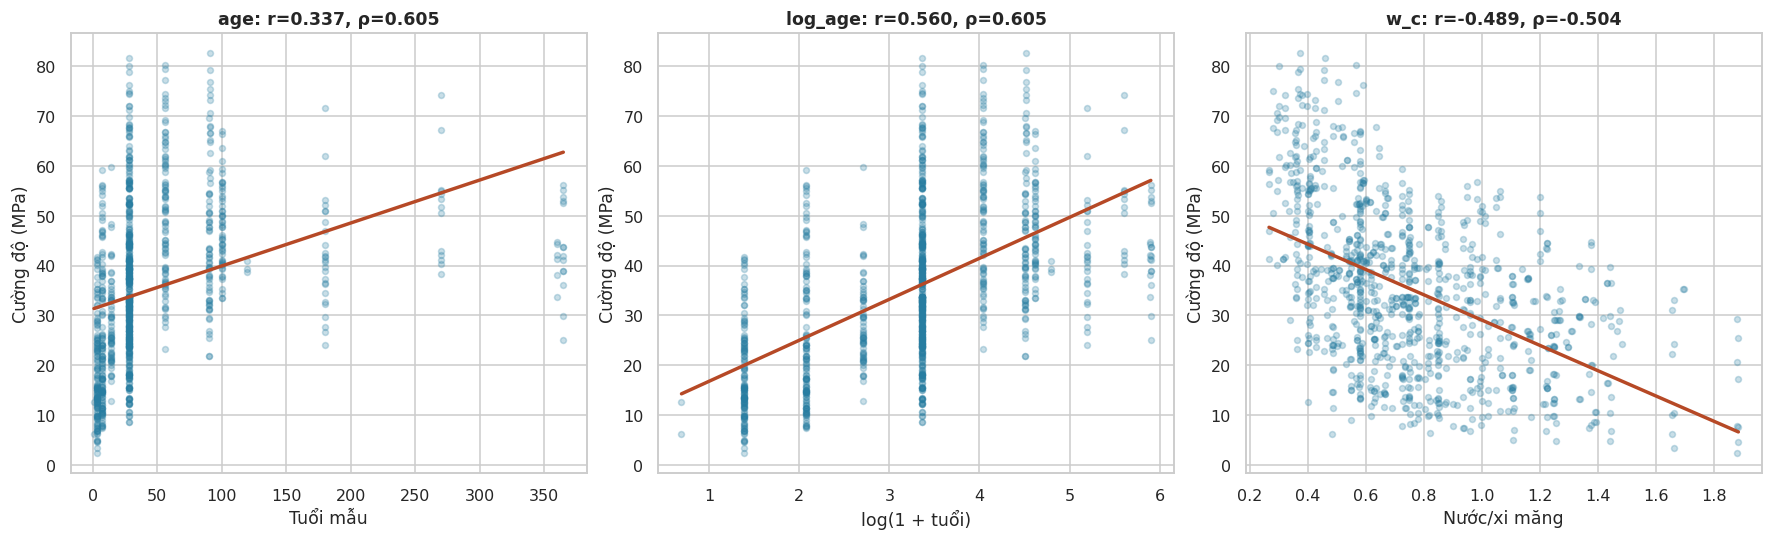

Spearman(cement, w_c) = -0.9567


In [6]:
derived_cols = ["age", "log_age", "water", "cement", "w_c"]
derived_table = pd.DataFrame({"Pearson": df[derived_cols+["strength"]].corr()["strength"].drop("strength"),
                              "Spearman": df[derived_cols+["strength"]].corr(method="spearman")["strength"].drop("strength")})
show_table(derived_table, "05_derived_variables")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), layout="constrained")
for ax, v in zip(axes, ["age", "log_age", "w_c"]):
    sns.regplot(data=df, x=v, y="strength", ci=None, ax=ax,
                scatter_kws={"alpha":.25, "s":15, "color":"#277DA1"}, line_kws={"color":"#B64926"})
    ax.set(xlabel=labels[v], ylabel="Cường độ (MPa)",
           title=f"{v}: r={derived_table.loc[v,'Pearson']:.3f}, ρ={derived_table.loc[v,'Spearman']:.3f}")
show_fig(fig, "05_age_log_ratio")
print("Spearman(cement, w_c) =", round(df["cement"].corr(df["w_c"], method="spearman"), 4))

**Nhận xét:** Pearson của tuổi với cường độ tăng từ khoảng 0,337 lên 0,560 khi dùng log tuổi, còn Spearman giữ nguyên khoảng 0,605. Biến đổi log giúp liên hệ gần tuyến tính hơn trong dữ liệu này nhưng không chứng minh một quy luật tăng trưởng cụ thể. `w_c` có Spearman khoảng −0,504, lớn hơn về trị tuyệt đối so với nước riêng lẻ (≈ −0,284).

Không xem `age` và `log_age` là hai nguồn thông tin độc lập. Spearman bằng 1 giữa chúng thể hiện trùng thứ hạng, **không** có nghĩa chúng là tổ hợp tuyến tính chính xác. `cement` và `w_c` có Spearman khoảng −0,957 do cấu trúc tỷ lệ; cần kiểm tra đa cộng tuyến nếu cùng đưa vào mô hình.

## 6. Tương quan giữa các biến đầu vào
Xét 28 cặp khác nhau của 8 đầu vào gốc, bỏ đường chéo và không đếm lặp A–B/B–A. Bảng dưới hiển thị 10 cặp lớn nhất theo |Spearman|. Tương quan cặp giúp sàng lọc sự phụ thuộc; nó không thay thế kiểm tra đa cộng tuyến toàn bộ ma trận thiết kế.

,bien_1,bien_2,Pearson,Spearman,abs_Spearman
0,water,superplasticizer,-0.6469,-0.6720,0.6720
1,fly_ash,superplasticizer,0.4141,0.5017,0.5017
2,cement,fly_ash,-0.3856,-0.4070,0.4070
3,slag,coarse_agg,-0.2776,-0.3414,0.3414
4,water,fine_agg,-0.4449,-0.3379,0.3379
5,fly_ash,water,-0.2834,-0.3144,0.3144
6,slag,fine_agg,-0.2897,-0.3002,0.3002
7,cement,slag,-0.3033,-0.2847,0.2847
8,water,coarse_agg,-0.2125,-0.2560,0.2560
9,slag,fly_ash,-0.3123,-0.2291,0.2291


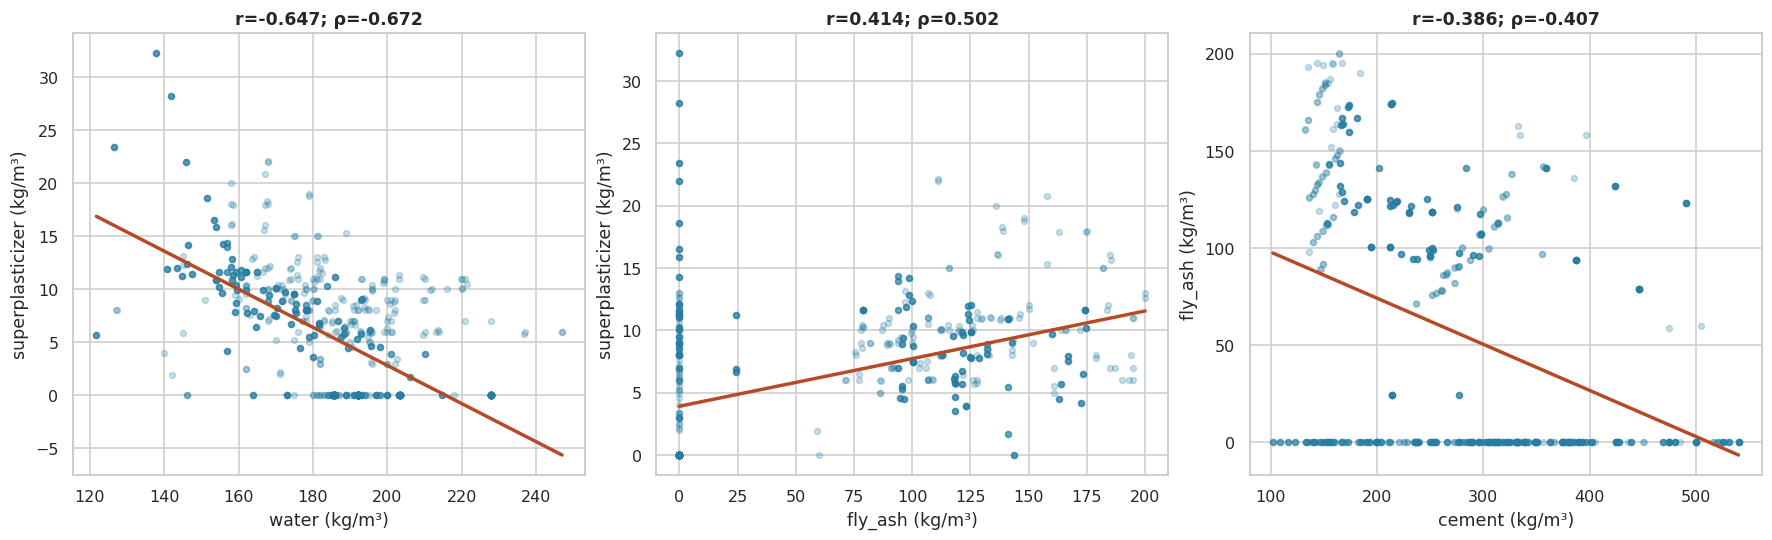

In [7]:
from itertools import combinations
pair_table = pd.DataFrame([{"bien_1": a, "bien_2": b, "Pearson": pearson.loc[a,b], "Spearman": spearman.loc[a,b]}
                           for a,b in combinations(features, 2)])
pair_table["abs_Spearman"] = pair_table["Spearman"].abs()
pair_table = pair_table.sort_values("abs_Spearman", ascending=False).reset_index(drop=True)
show_table(pair_table.head(10), "06_top_input_pairs")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), layout="constrained")
for ax, row in zip(axes, pair_table.head(3).itertuples()):
    sns.regplot(data=df, x=row.bien_1, y=row.bien_2, ci=None, ax=ax,
                scatter_kws={"alpha":.25,"s":15,"color":"#277DA1"}, line_kws={"color":"#B64926"})
    ax.set_title(f"r={row.Pearson:.3f}; ρ={row.Spearman:.3f}")
    ax.set_xlabel(f"{row.bien_1} ({'ngày' if row.bien_1 == 'age' else 'kg/m³'})")
    ax.set_ylabel(f"{row.bien_2} ({'ngày' if row.bien_2 == 'age' else 'kg/m³'})")
show_fig(fig, "06_top_input_scatter")
if EXPORT: pair_table.to_csv(OUT / "06_all_input_pairs.csv", index=False, encoding="utf-8-sig")

**Cách diễn giải:** Quan hệ âm giữa nước và phụ gia siêu dẻo phù hợp với giả thuyết cấp phối dùng phụ gia để giảm nước, nhưng dữ liệu tương quan không chứng minh giả thuyết đó. Các quan hệ âm giữa vật liệu có thể phản ánh cách thay thế thành phần trong cấp phối. Không tự động loại biến chỉ vì |r| hoặc |ρ| vượt một ngưỡng; ngược lại, hệ số cặp nhỏ cũng không đảm bảo không có đa cộng tuyến nhiều biến.

## 7. Tuổi mẫu có làm thay đổi các liên hệ?
### 7.1. Phân tích riêng mẫu 28 ngày
Mốc 28 ngày là nhóm lớn nhất. So sánh trên cùng tuổi giúp loại bỏ biến thiên tuổi trong tập con, nhưng đồng thời thay đổi tập cấp phối quan sát. Không diễn giải chênh lệch hệ số như tác động thuần túy của việc kiểm soát tuổi.

In [8]:
df28 = df.loc[df["age"].eq(28)]
materials = features[:-1]
age28_table = pd.DataFrame({"rho_toan_mau": df[materials+["strength"]].corr(method="spearman")["strength"].drop("strength"),
                            "rho_28_ngay": df28[materials+["strength"]].corr(method="spearman")["strength"].drop("strength")})
age28_table["chenh_lech"] = age28_table["rho_28_ngay"] - age28_table["rho_toan_mau"]
print(f"Toàn mẫu: n={len(df)}; chỉ 28 ngày: n={len(df28)} ({len(df28)/len(df):.1%}).")
show_table(age28_table, "07_correlations_at_28_days")

,rho_toan_mau,rho_28_ngay,chenh_lech
cement,0.4614,0.6473,0.1859
slag,0.1386,0.1541,0.0154
fly_ash,-0.0565,-0.2230,-0.1665
water,-0.2842,-0.3497,-0.0655
superplasticizer,0.3218,0.1843,-0.1375
coarse_agg,-0.1628,-0.1430,0.0199
fine_agg,-0.1933,-0.1880,0.0053


Toàn mẫu: n=1005; chỉ 28 ngày: n=419 (41.7%).


### 7.2. Tương quan Pearson riêng phần sau điều chỉnh log tuổi
Hồi quy từng biến vật liệu lên hằng số và `log_age`, làm tương tự với `strength`, rồi tính Pearson giữa hai phần dư. Đây là điều chỉnh **tuyến tính theo log tuổi**, không kiểm soát toàn bộ cấp phối và không loại bỏ mọi nhiễu.

,Pearson_bien,Pearson_dieu_chinh_log_age
cement,0.4883,0.5850
slag,0.1034,0.1378
fly_ash,-0.0806,-0.0822
water,-0.2696,-0.4482
superplasticizer,0.3442,0.4473
coarse_agg,-0.1447,-0.1463
fine_agg,-0.1865,-0.1478


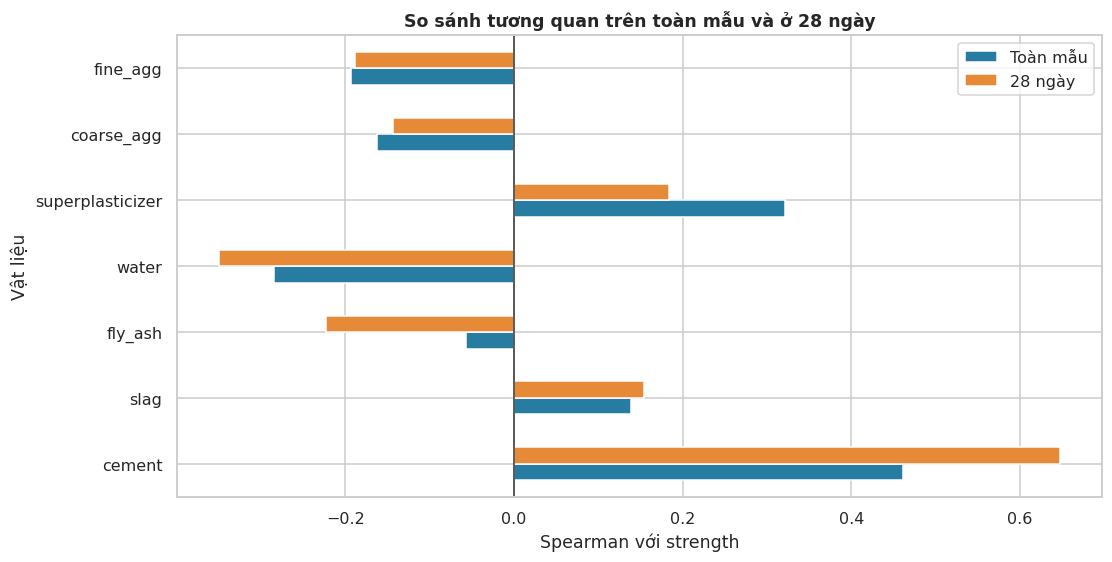

**Các biến thay đổi nhiều nhất khi xét riêng 28 ngày:** `cement`: 0.461 → 0.647; `fly_ash`: -0.056 → -0.223; `superplasticizer`: 0.322 → 0.184. Sự thay đổi cho thấy cần đọc hệ số trong bối cảnh tuổi và tập cấp phối; không dùng tương quan biên làm kết luận về hiệu quả riêng của vật liệu.

In [9]:
Z = np.column_stack([np.ones(len(df)), df["log_age"].to_numpy()])
def residuals_on_log_age(values):
    y = np.asarray(values, dtype=float)
    return y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
strength_residuals = residuals_on_log_age(df["strength"])
partial_table = pd.DataFrame({"Pearson_bien": [pearson.loc[v,"strength"] for v in materials],
                              "Pearson_dieu_chinh_log_age": [stats.pearsonr(residuals_on_log_age(df[v]), strength_residuals)[0] for v in materials]}, index=materials)
show_table(partial_table, "08_partial_pearson")
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
age28_table[["rho_toan_mau","rho_28_ngay"]].rename(columns={"rho_toan_mau":"Toàn mẫu", "rho_28_ngay":"28 ngày"}).plot.barh(ax=ax, color=["#277DA1","#E78A38"])
ax.axvline(0,color="#333333",lw=1)
ax.set(xlabel="Spearman với strength", ylabel="Vật liệu", title="So sánh tương quan trên toàn mẫu và ở 28 ngày")
show_fig(fig, "07_age_control")
changes = age28_table["chenh_lech"].abs().sort_values(ascending=False).head(3)
display(Markdown("**Các biến thay đổi nhiều nhất khi xét riêng 28 ngày:** " + "; ".join(
    f"`{v}`: {age28_table.loc[v,'rho_toan_mau']:.3f} → {age28_table.loc[v,'rho_28_ngay']:.3f}" for v in changes.index) +
    ". Sự thay đổi cho thấy cần đọc hệ số trong bối cảnh tuổi và tập cấp phối; không dùng tương quan biên làm kết luận về hiệu quả riêng của vật liệu."))

## 8. Kiểm tra độ nhạy với các cờ ngoại lai
Giữ toàn bộ 1.005 dòng cho kết quả chính, đúng quyết định của nhóm. Chỉ so sánh với các tập con bỏ dòng bị gắn cờ IQR, Z-score hoặc MAD. Cờ của nhóm được tạo trên nhiều biến, **có cả strength**, nên việc bỏ cờ có thể tạo thiên lệch chọn mẫu và thu hẹp miền biến thiên. Đây không phải đề xuất xóa dữ liệu.

Với biến nhiều số 0, MAD có thể bằng 0 hoặc rất nhỏ; nhóm không áp dụng Modified Z-score cho `fly_ash`. Không xem “không có cờ” đồng nghĩa dữ liệu tốt hơn.

,n
Toan_mau,1005
Bo_co_IQR,895
Bo_co_Z,948
Bo_co_MAD,658


,Toan_mau,Bo_co_IQR,Bo_co_Z,Bo_co_MAD
cement,0.4614,0.4125,0.4361,0.4386
slag,0.1386,0.1691,0.1612,0.2908
fly_ash,-0.0565,-0.0068,-0.0344,-0.0418
water,-0.2842,-0.3295,-0.3123,-0.3548
superplasticizer,0.3218,0.3489,0.3415,0.3365
coarse_agg,-0.1628,-0.1654,-0.1577,-0.1668
fine_agg,-0.1933,-0.1608,-0.1807,-0.1456
age,0.6054,0.6143,0.6082,0.6035
w_c,-0.5038,-0.4766,-0.4924,-0.5147


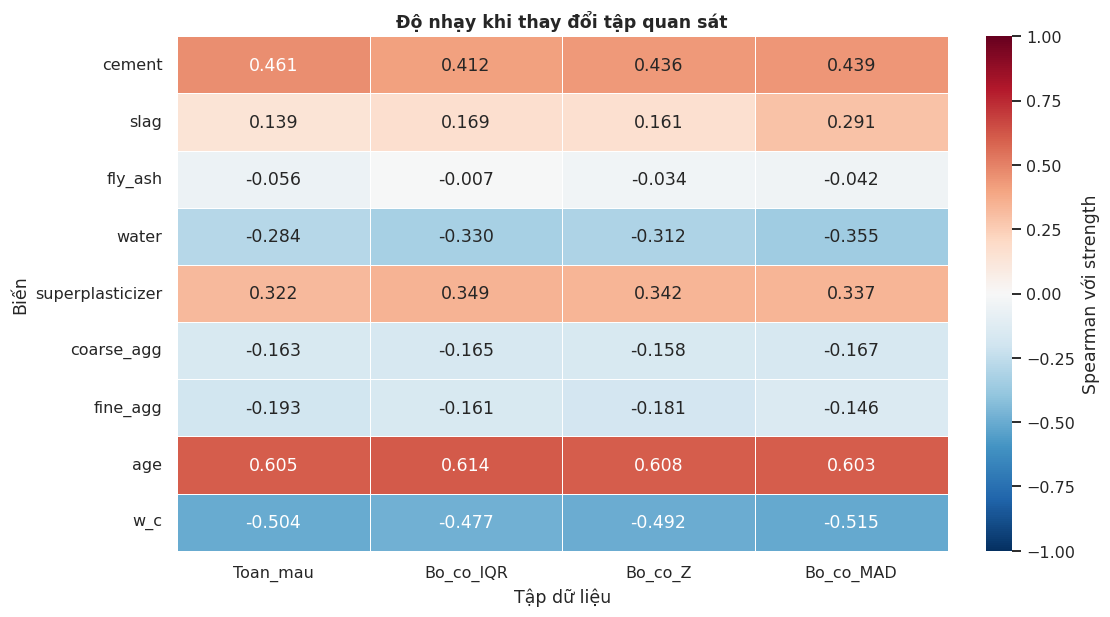

**Độ thay đổi tuyệt đối lớn nhất qua ba kịch bản:** `slag`: 0.152; `water`: 0.071; `fly_ash`: 0.050. Sự khác nhau có thể phản ánh việc loại các tuổi dài ngày hoặc cấp phối hiếm, không nhất thiết là sửa được sai số.

In [10]:
sensitivity_cols = features + ["w_c"]
subsets = {"Toan_mau": df}
for label, flag in [("Bo_co_IQR", "outlier_iqr_any"), ("Bo_co_Z", "outlier_zscore_any"), ("Bo_co_MAD", "outlier_mad_any")]:
    # Đọc rõ boolean để tránh bool("False") trả về True.
    values = df[flag].astype(str).str.lower()
    assert values.isin(["true", "false"]).all()
    subsets[label] = df.loc[values.eq("false")]
sensitivity = pd.DataFrame({name: data[sensitivity_cols+["strength"]].corr(method="spearman")["strength"].drop("strength")
                            for name,data in subsets.items()})
show_table(pd.DataFrame({"n": {k:len(v) for k,v in subsets.items()}}), "09_sensitivity_sizes")
show_table(sensitivity, "09_sensitivity_spearman")
fig, ax = plt.subplots(figsize=(10, 5.5), layout="constrained")
sns.heatmap(sensitivity, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=.5, ax=ax, cbar_kws={"label":"Spearman với strength"})
ax.set(title="Độ nhạy khi thay đổi tập quan sát", xlabel="Tập dữ liệu", ylabel="Biến")
show_fig(fig, "08_sensitivity")
max_change = sensitivity.drop(columns="Toan_mau").sub(sensitivity["Toan_mau"], axis=0).abs().max(axis=1).sort_values(ascending=False)
display(Markdown("**Độ thay đổi tuyệt đối lớn nhất qua ba kịch bản:** " + "; ".join(f"`{v}`: {d:.3f}" for v,d in max_change.head(3).items()) +
                 ". Sự khác nhau có thể phản ánh việc loại các tuổi dài ngày hoặc cấp phối hiếm, không nhất thiết là sửa được sai số."))

## 9. Kết luận để đưa vào báo cáo nhóm
1. Trên 1.005 quan sát sau làm sạch, tuổi mẫu có tương quan đơn điệu lớn nhất với cường độ trong các đầu vào gốc (Spearman ≈ **0,605**); xi măng có tương quan tuyến tính lớn nhất (Pearson ≈ **0,488**). Đây là hai kết quả theo hai thước đo khác nhau.
2. Quan hệ tuổi–cường độ không được mô tả đầy đủ bằng một đường thẳng trên tuổi gốc. Dùng `log(1 + age)` làm Pearson tăng từ khoảng **0,337** lên **0,560**, còn Spearman không đổi.
3. Tỷ lệ nước/xi măng có tương quan âm với cường độ (Spearman ≈ **−0,504**), rõ hơn nước riêng lẻ (≈ **−0,284**). Tỷ lệ này là biến dẫn xuất, có quan hệ toán học chặt với xi măng nên cần thận trọng khi đưa đồng thời vào mô hình.
4. Các đầu vào không độc lập: nước và phụ gia siêu dẻo có quan hệ âm đáng chú ý. Các cặp tương quan và biến dẫn xuất cần được xem xét trước khi xây dựng hồi quy.
5. Hệ số thay đổi khi giới hạn mẫu ở 28 ngày hoặc thay đổi cách lọc cờ ngoại lai. Vì vậy, cần trình bày rõ mẫu phân tích và không xem hệ số tương quan biên là hiệu quả riêng của từng vật liệu.

**Giới hạn:** Dữ liệu quan sát theo thiết kế thí nghiệm không cân bằng tuổi; có các công thức cấp phối lặp qua nhiều tuổi và không có mã thí nghiệm độc lập. Hệ số nhỏ không loại trừ quan hệ phi tuyến, tương tác hay tác động bị che khuất bởi các thành phần khác. Tương quan không chứng minh nhân quả, và không đủ để chọn toàn bộ biến cho mô hình dự đoán.

**Gợi ý cho phần tiếp theo của nhóm:** cân nhắc log tuổi; kiểm tra đa cộng tuyến trên tập biến thực sự sử dụng; đánh giá thêm quan hệ phi tuyến và tương tác tuổi–vật liệu. Khi đánh giá mô hình, cần xử lý việc cùng cấp phối xuất hiện ở nhiều tuổi để tránh đánh giá quá lạc quan.

## 10. Kiểm tra tính nhất quán và tài liệu nguồn
Kết quả phải khớp phần Spearman đã có trong EDA của nhóm. Kiểm tra cuối đối chiếu file đó nếu notebook đang chạy trong repo.

**Tài liệu:**
- [Repo nhóm và phiên bản dữ liệu](https://github.com/vkyphong/concrete-compressive-strength-analysis/tree/cd7509dc0d1734cf8c9382b5127c4bfbcd769e44).
- `report/eda_summary.md`, `data/processed/README.md`, `tables/data_dictionary.csv`, `data/raw/Concrete_Readme.txt` trong repo.
- Nguồn dữ liệu gốc theo README: Prof. I-Cheng Yeh, *Modeling of strength of high performance concrete using artificial neural networks*, Cement and Concrete Research, 28(12), 1797–1808 (1998). Giữ ghi nhận tác giả và nguồn khi tái sử dụng dữ liệu.

Các số trong phần nhận xét được viết cho đúng snapshot có SHA-256 ghi ở mục 1. Nếu nhóm thay dữ liệu, cần chạy lại **và cập nhật nhận xét**, không chỉ cập nhật biểu đồ.

In [11]:
assert np.allclose(pearson, pearson.T)
assert np.allclose(spearman, spearman.T)
assert np.allclose(np.diag(pearson), 1)
assert len(pair_table) == 28
assert np.isclose(df["age"].corr(df["log_age"], method="spearman"), 1)
assert np.isclose(derived_table.loc["age","Spearman"], derived_table.loc["log_age","Spearman"])
assert len(df28) == 419
assert [len(subsets[k]) for k in ["Toan_mau","Bo_co_IQR","Bo_co_Z","Bo_co_MAD"]] == [1005,895,948,658]
eda_candidates = [Path.cwd()/"tables/spearman_correlation.csv", Path.cwd().parent/"tables/spearman_correlation.csv"]
eda_file = next((p for p in eda_candidates if p.exists()), None)
if eda_file:
    eda_corr = pd.read_csv(eda_file, index_col=0)
    assert np.allclose(spearman, eda_corr.loc[original, original])
    print("Đã đối chiếu: Spearman khớp bảng EDA hiện có của nhóm.")
print("Hoàn tất: ma trận hợp lệ, số mẫu đúng, các biến dẫn xuất nhất quán.")
print("Xuất PNG/CSV:", "Đã bật tại " + str(OUT) if EXPORT else "Đang tắt; bật EXPORT=True ở ô đầu nếu cần.")

Đã đối chiếu: Spearman khớp bảng EDA hiện có của nhóm.
Hoàn tất: ma trận hợp lệ, số mẫu đúng, các biến dẫn xuất nhất quán.
Xuất PNG/CSV: Đang tắt; bật EXPORT=True ở ô đầu nếu cần.
